In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("\n" + "="*60)
print("  STEP 1: Loading Data")
print("="*60)

df = pd.read_csv("/content/Predicting Impulse Buying Behavior Using Psychological and Environmental Factors – Research Survey.csv")
print(f"  Loaded {len(df)} responses with {len(df.columns)} columns")
print(f"\n  Columns found:")
for col in df.columns:
    print(f"    - {col}")


  STEP 1: Loading Data
  Loaded 296 responses with 33 columns

  Columns found:
    - Timestamp
    - Age
    - Gender
    - Occupation 
    - Which platform did you use for your recent purchase?  
    - Device used during purchase  
    - How often do you shop Online ?
    - Think about your most recent online purchase. Was it planned in advance?  
    -   Did you originally intend to buy this product before opening the app/website?  
    - How much time did you spend browsing before purchasing?  
    - I often buy things when I am feeling stressed.  
    - I shop online to improve my mood.  
    -  I find it hard to resist attractive offers.  
    - I experience FOMO (Fear of Missing Out) during flash sales.  
    - I sometimes buy products without thinking about future need.  
    - I feel excited while making spontaneous (Random)  purchases. 
    - I regret some purchases later. 
    - I consider myself emotionally influenced while shopping. 
    - Was the product on discount? 
  

In [ ]:
print("\n" + "="*60)
print("  STEP 2: Cleaning & Renaming Columns")
print("="*60)

column_map = {
    df.columns[1]:  "age",
    df.columns[2]:  "gender",
    df.columns[3]:  "occupation",
    df.columns[4]:  "platform",
    df.columns[5]:  "device",
    df.columns[6]:  "shop_frequency",
    df.columns[7]:  "purchase_planned",
    df.columns[8]:  "intended_before_opening",
    df.columns[9]:  "browsing_time",
    df.columns[10]: "stress_buying",
    df.columns[11]: "mood_shopping",
    df.columns[12]: "hard_resist_offers",
    df.columns[13]: "fomo_flash_sales",
    df.columns[14]: "buy_without_need",
    df.columns[15]: "excited_spontaneous",
    df.columns[16]: "regret_purchases",
    df.columns[17]: "emotionally_influenced",
    df.columns[18]: "product_on_discount",
    df.columns[19]: "limited_time_offer",
    df.columns[20]: "influencer_influenced",
    df.columns[21]: "push_notification",
    df.columns[22]: "discount_percentage",
    df.columns[23]: "peer_recommendation",
    df.columns[24]: "payment_method",
    df.columns[25]: "compare_prices",
    df.columns[26]: "add_cart_no_buy",
    df.columns[27]: "impulse_count_monthly",
    df.columns[28]: "plan_purchases",
    df.columns[29]: "stick_budget",
    df.columns[30]: "comfortable_spending",
    df.columns[31]: "review_expenses",
    df.columns[32]: "classify_purchase",
}

df.rename(columns=column_map, inplace=True)
df.drop(columns=[df.columns[0]], inplace=True, errors='ignore')  # Drop timestamp
print(f"  Columns renamed successfully")


  STEP 2: Cleaning & Renaming Columns
  Columns renamed successfully


In [ ]:
df.head()

,age,gender,occupation,platform,device,shop_frequency,purchase_planned,intended_before_opening,browsing_time,stress_buying,...,peer_recommendation,payment_method,compare_prices,add_cart_no_buy,impulse_count_monthly,plan_purchases,stick_budget,comfortable_spending,review_expenses,classify_purchase
0,21 - 24,Male,Student,Flipkart,Mobile Browser,2 - 3 times a month,Yes,Yes,Less than 5 minutes,3,...,Yes,"UPI (Gpay, Phonepe, Paytm)",Always,Sometimes,1 - 2,4,4,4,4,Partially Planned
1,21 - 24,Male,Student,Amazon,Mobile App,Rarely,Yes,Yes,Less than 5 minutes,1,...,No,"UPI (Gpay, Phonepe, Paytm)",Sometimes,Rarely,0,4,4,2,3,Completely Planned
2,21 - 24,Female,Student,Amazon,Mobile App,Rarely,No,Yes,15 - 30 minutes,3,...,No,"UPI (Gpay, Phonepe, Paytm)",Always,Always,1 - 2,3,5,1,5,Completely Planned
3,21 - 24,Male,Student,Amazon,Mobile App,Rarely,Yes,Yes,15 - 30 minutes,1,...,No,"UPI (Gpay, Phonepe, Paytm)",Always,Sometimes,0,4,4,2,4,Completely Planned
4,21 - 24,Male,Working Professional,Ajio,Mobile App,2 - 3 times a month,Yes,Yes,15 - 30 minutes,2,...,No,"UPI (Gpay, Phonepe, Paytm)",Always,Always,1 - 2,2,4,3,2,Completely Planned


In [ ]:
print("\n" + "="*60)
print("  STEP 3: Creating Target Variable")
print("="*60)

def create_target(val):
    val = str(val).strip().lower()
    if "unplanned" in val:
        return 1  # Impulse buyer
    elif "partially" in val:
        return 1  # Also impulse (partial = some impulsivity)
    else:
        return 0  # Planned buyer

df["is_impulse"] = df["classify_purchase"].apply(create_target)
print(f"  Target distribution:")
print(f"    Impulse buyers  (1): {df['is_impulse'].sum()} ({df['is_impulse'].mean()*100:.1f}%)")
print(f"    Planned buyers  (0): {(df['is_impulse']==0).sum()} ({(df['is_impulse']==0).mean()*100:.1f}%)")


  STEP 3: Creating Target Variable
  Target distribution:
    Impulse buyers  (1): 213 (72.0%)
    Planned buyers  (0): 83 (28.0%)


In [ ]:
print("\n" + "="*60)
print("  STEP 4: Encoding Categorical Variables")
print("="*60)

# Binary Yes/No columns → 1/0
binary_cols = [
    "purchase_planned", "intended_before_opening",
    "product_on_discount", "limited_time_offer",
    "influencer_influenced", "push_notification", "peer_recommendation"
]
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({"Yes": 1, "No": 0})

# Age → ordinal numeric
age_map = {"16 - 20": 1, "21 - 24": 2, "25 - 29": 3, "30 - 34": 4, "35 +": 5}
df["age"] = df["age"].map(age_map)

# Shopping frequency → ordinal
freq_map = {
    "Rarely": 1, "Once a month": 2,
    "2 - 3 times a month": 3, "Weekly": 4,
    "Multiple times in a month": 5
}
df["shop_frequency"] = df["shop_frequency"].map(freq_map)

# Browsing time → ordinal
browse_map = {
    "Less than 5 minutes": 1, "5 - 15 minutes": 2,
    "15 - 30 minutes": 3, "more than 30 minutes": 4
}
df["browsing_time"] = df["browsing_time"].map(browse_map)

# Discount percentage → ordinal
disc_map = {
    "No Discount": 0, "0 - 10 %": 1,
    "10 - 30 %": 2, "30 - 50 %": 3, "More than 50%": 4
}
df["discount_percentage"] = df["discount_percentage"].map(disc_map)

# Compare prices → ordinal
compare_map = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Always": 4}
df["compare_prices"] = df["compare_prices"].map(compare_map)
df["add_cart_no_buy"] = df["add_cart_no_buy"].map(compare_map)

# Impulse count → ordinal
impulse_map = {"0": 0, "1 - 2": 1, "3 - 5": 2, "More than 5": 3}
df["impulse_count_monthly"] = df["impulse_count_monthly"].map(impulse_map)

# Label encode remaining categorical columns
le = LabelEncoder()
for col in ["gender", "occupation", "platform", "device", "payment_method"]:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

print(f"  All categorical variables encoded")
print(f"  Missing values: {df.isnull().sum().sum()}")
df.fillna(df.median(numeric_only=True), inplace=True)
print(f"  Missing values after fill: {df.isnull().sum().sum()}")


  STEP 4: Encoding Categorical Variables
  All categorical variables encoded
  Missing values: 0
  Missing values after fill: 0


In [ ]:
print("\n" + "="*60)
print("  STEP 5: Feature Engineering")
print("="*60)

# Psychological Impulse Score (avg of all Likert psychological factors)
psych_cols = ["stress_buying", "mood_shopping", "hard_resist_offers",
              "fomo_flash_sales", "buy_without_need", "excited_spontaneous",
              "regret_purchases", "emotionally_influenced"]
df["psych_impulse_score"] = df[psych_cols].mean(axis=1)

# Environmental Trigger Score
env_cols = ["product_on_discount", "limited_time_offer",
            "influencer_influenced", "push_notification", "peer_recommendation"]
df["env_trigger_score"] = df[env_cols].sum(axis=1)

# Self-Control Score (inverse = lower score = less control)
self_ctrl_cols = ["plan_purchases", "stick_budget", "review_expenses"]
df["self_control_score"] = df[self_ctrl_cols].mean(axis=1)

# Impulse Risk Score (composite — higher = more likely impulse buyer)
df["impulse_risk_score"] = (
    df["psych_impulse_score"] * 0.4 +
    df["env_trigger_score"] * 0.3 +
    (6 - df["self_control_score"]) * 0.3  # invert self control
)

print(f"  Created engineered features:")
print(f"    psych_impulse_score  : avg of 8 psychological Likert items")
print(f"    env_trigger_score    : sum of 5 environmental triggers")
print(f"    self_control_score   : avg of planning/budget Likert items")
print(f"    impulse_risk_score   : composite score (higher = more impulsive)")


  STEP 5: Feature Engineering
  Created engineered features:
    psych_impulse_score  : avg of 8 psychological Likert items
    env_trigger_score    : sum of 5 environmental triggers
    self_control_score   : avg of planning/budget Likert items
    impulse_risk_score   : composite score (higher = more impulsive)


In [ ]:
FEATURES = [
    # Demographics
    "age", "gender", "occupation",
    # Shopping behavior
    "platform", "device", "shop_frequency",
    # Purchase context
    "purchase_planned", "intended_before_opening", "browsing_time",
    # Psychological factors
    "stress_buying", "mood_shopping", "hard_resist_offers",
    "fomo_flash_sales", "buy_without_need", "excited_spontaneous",
    "regret_purchases", "emotionally_influenced",
    # Environmental triggers
    "product_on_discount", "limited_time_offer", "influencer_influenced",
    "push_notification", "discount_percentage", "peer_recommendation",
    # Payment & behavior
    "payment_method", "compare_prices", "add_cart_no_buy", "impulse_count_monthly",
    # Decision behavior
    "plan_purchases", "stick_budget", "comfortable_spending", "review_expenses",
    # Engineered features
    "psych_impulse_score", "env_trigger_score", "self_control_score", "impulse_risk_score"
]

TARGET = "is_impulse"

X = df[FEATURES]
y = df[TARGET]

In [ ]:
print("\n" + "="*60)
print("  STEP 6: Train/Test Split")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"  Training set : {len(X_train)} samples")
print(f"  Test set     : {len(X_test)} samples")




  STEP 6: Train/Test Split
  Training set : 236 samples
  Test set     : 60 samples


In [ ]:
print("\n" + "="*60)
print("  STEP 7: Training Models")
print("="*60)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=4, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
}

results = {}
for name, model in models.items():
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled  if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)
    cv      = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy').mean()

    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "accuracy": acc, "auc": auc, "cv_accuracy": cv,
        "X_te": X_te
    }
    print(f"\n  {name}:")
    print(f"    Accuracy     : {acc*100:.2f}%")
    print(f"    ROC-AUC      : {auc:.4f}")
    print(f"    CV Accuracy  : {cv*100:.2f}%")


  STEP 7: Training Models

  Logistic Regression:
    Accuracy     : 70.00%
    ROC-AUC      : 0.7688
    CV Accuracy  : 74.57%

  Decision Tree:
    Accuracy     : 66.67%
    ROC-AUC      : 0.6915
    CV Accuracy  : 72.04%

  Random Forest:
    Accuracy     : 73.33%
    ROC-AUC      : 0.8222
    CV Accuracy  : 72.88%

  Gradient Boosting:
    Accuracy     : 75.00%
    ROC-AUC      : 0.7880
    CV Accuracy  : 71.21%


In [ ]:
print("\n── Full Model Scorecard ──────────────────────────────")
print(f"{'Model':<25} {'Accuracy':>10} {'AUC':>8} {'CV Acc':>8} {'Score':>8}")
print("-" * 60)
for name, res in results.items():
    combined = (res["accuracy"] * 0.25 +
                res["auc"]      * 0.25 +
                res["cv_accuracy"] * 0.50)
    res["combined_score"] = combined
    print(f"{name:<25} {res['accuracy']*100:>9.1f}% {res['auc']:>8.3f} {res['cv_accuracy']*100:>7.1f}% {combined:>8.3f}")

# Now pick best using all metrics
best_name = max(results, key=lambda k: results[k]["combined_score"])
print(f"\n  ★ Best Model: {best_name} ★")


── Full Model Scorecard ──────────────────────────────
Model                       Accuracy      AUC   CV Acc    Score
------------------------------------------------------------
Logistic Regression            70.0%    0.769    74.6%    0.740
Decision Tree                  66.7%    0.692    72.0%    0.700
Random Forest                  73.3%    0.822    72.9%    0.753
Gradient Boosting              75.0%    0.788    71.2%    0.741

  ★ Best Model: Random Forest ★


In [ ]:
print("\n" + "="*60)
print(f"  STEP 8: Detailed Report — {best_name}")
print("="*60)
print(classification_report(y_test, best["y_pred"],
      target_names=["Planned Buyer", "Impulse Buyer"]))


  STEP 8: Detailed Report — Random Forest
               precision    recall  f1-score   support

Planned Buyer       0.54      0.41      0.47        17
Impulse Buyer       0.79      0.86      0.82        43

     accuracy                           0.73        60
    macro avg       0.66      0.64      0.64        60
 weighted avg       0.72      0.73      0.72        60



In [ ]:
print("\n" + "="*60)
print("  STEP 9: Top Feature Importances")
print("="*60)

best_model = best["model"]
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(feat_imp.head(10).to_string(index=False))


  STEP 9: Top Feature Importances
                Feature  Importance
    psych_impulse_score    0.086536
     impulse_risk_score    0.070201
intended_before_opening    0.065601
     self_control_score    0.047293
   comfortable_spending    0.044699
       buy_without_need    0.040475
     hard_resist_offers    0.039572
           stick_budget    0.039283
          browsing_time    0.039171
    excited_spontaneous    0.035783


In [ ]:
print("\n" + "="*60)
print("  STEP 10: Impulse Risk Score Segmentation")
print("="*60)

df["risk_segment"] = pd.cut(
    df["impulse_risk_score"],
    bins=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)
print(df["risk_segment"].value_counts().to_string())


  STEP 10: Impulse Risk Score Segmentation
risk_segment
Medium Risk    123
High Risk       94
Low Risk        79



  STEP 11: Saving Visualizations
  Saved: model_results.png
  Saved: feature_importance.png


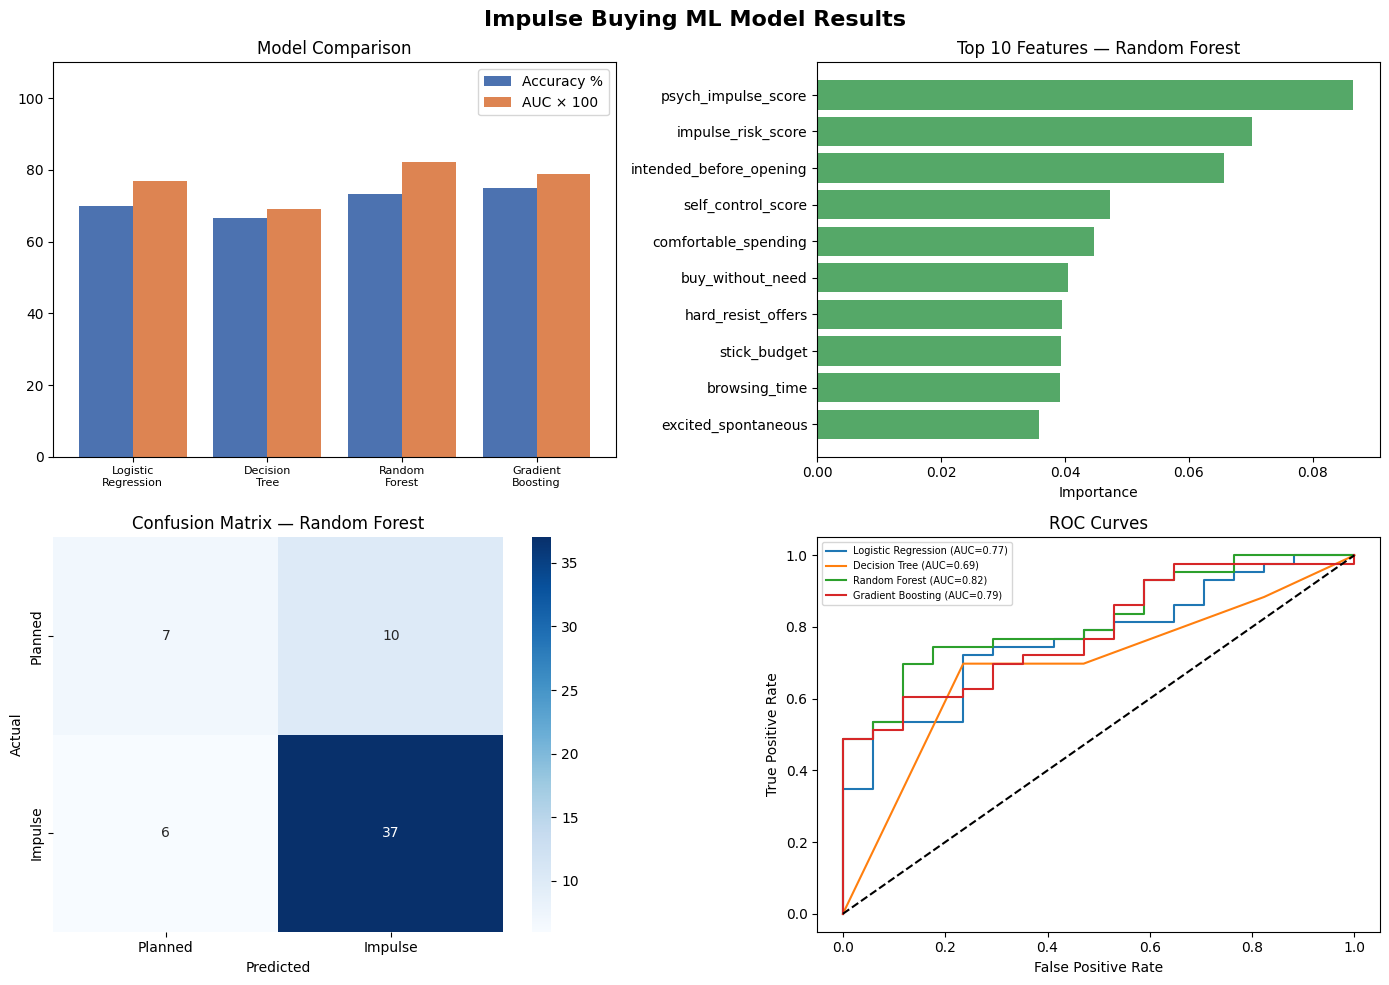

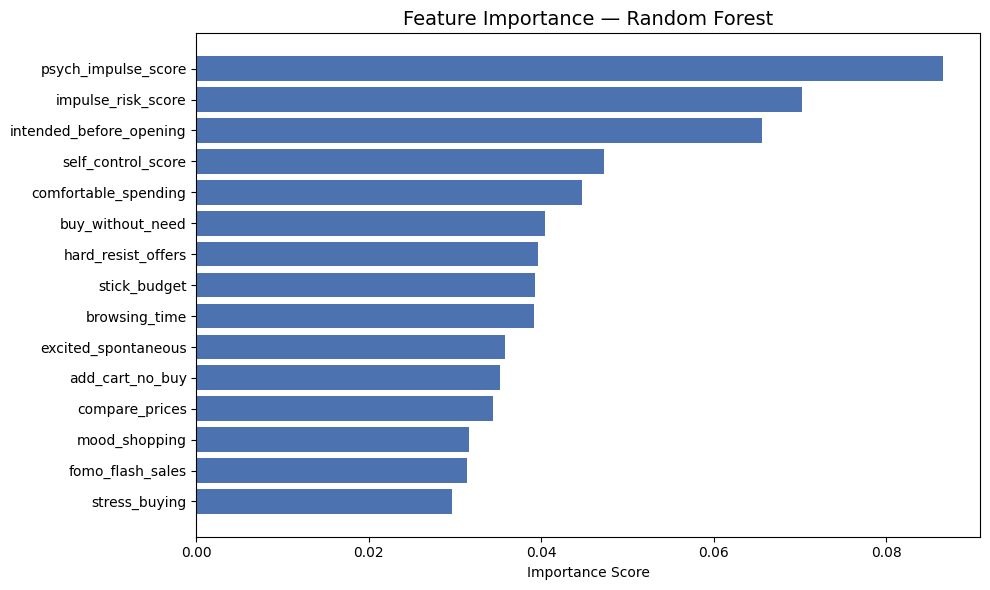

In [ ]:
print("\n" + "="*60)
print("  STEP 11: Saving Visualizations")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Impulse Buying ML Model Results", fontsize=16, fontweight='bold')

# Plot 1: Model Comparison
ax = axes[0, 0]
names = list(results.keys())
accs  = [results[n]["accuracy"]*100 for n in names]
aucs  = [results[n]["auc"] for n in names]
x = np.arange(len(names))
bars = ax.bar(x - 0.2, accs, 0.4, label="Accuracy %", color="#4C72B0")
ax.bar(x + 0.2, [a*100 for a in aucs], 0.4, label="AUC × 100", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=8)
ax.set_title("Model Comparison")
ax.legend()
ax.set_ylim(0, 110)

# Plot 2: Feature Importance (top 10)
ax = axes[0, 1]
top10 = feat_imp.head(10)
ax.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="#55A868")
ax.set_title(f"Top 10 Features — {best_name}")
ax.set_xlabel("Importance")

# Plot 3: Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(y_test, best["y_pred"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=["Planned", "Impulse"],
            yticklabels=["Planned", "Impulse"])
ax.set_title(f"Confusion Matrix — {best_name}")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")

# Plot 4: ROC Curves
ax = axes[1, 1]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})")
ax.plot([0,1],[0,1],'k--')
ax.set_title("ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("model_results.png", dpi=150, bbox_inches='tight')
print("  Saved: model_results.png")

# Feature importance bar chart
plt.figure(figsize=(10, 6))
top15 = feat_imp.head(15)
plt.barh(top15["Feature"][::-1], top15["Importance"][::-1], color="#4C72B0")
plt.title(f"Feature Importance — {best_name}", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
print("  Saved: feature_importance.png")

In [ ]:
df.to_csv("processed_data.csv", index=False)
feat_imp.to_csv("feature_importance.csv", index=False)
print("  Saved: processed_data.csv")
print("  Saved: feature_importance.csv")

print("\n" + "="*60)
print("  ALL DONE! Files created:")
print("    model_results.png      → charts for your report")
print("    feature_importance.png → top predictors chart")
print("    processed_data.csv     → cleaned encoded dataset")
print("    feature_importance.csv → ranked feature scores")
print("="*60 + "\n")

  Saved: processed_data.csv
  Saved: feature_importance.csv

  ALL DONE! Files created:
    model_results.png      → charts for your report
    feature_importance.png → top predictors chart
    processed_data.csv     → cleaned encoded dataset
    feature_importance.csv → ranked feature scores

